In [1]:
print("Fraud Detection Project Started")

Fraud Detection Project Started


In [2]:
import os

file_path = "../data/raw/PS_20174392719_1491204439457_log.csv"

print("Checking dataset...")
print("File exists:", os.path.exists(file_path))

Checking dataset...
File exists: True


In [3]:
import pandas as pd

df_sample = pd.read_csv(file_path, nrows=1000)

print("Rows loaded:", len(df_sample))
print("Columns:", df_sample.shape[1])

df_sample.head()

Rows loaded: 1000
Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
print("Dataset shape:", df_sample.shape)
print("\nColumn names:")
print(df_sample.columns.tolist())

print("\nData types:")
print(df_sample.dtypes)


Dataset shape: (1000, 11)

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [5]:
print("Missing values:")
print(df_sample.isnull().sum())

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [6]:
print("Duplicate rows:", df_sample.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Fraud distribution:")
print(df_sample["isFraud"].value_counts())

print("\nFraud percentage:")
print(df_sample["isFraud"].value_counts(normalize=True) * 100)

Fraud distribution:
isFraud
0    991
1      9
Name: count, dtype: int64

Fraud percentage:
isFraud
0    99.1
1     0.9
Name: proportion, dtype: float64


In [8]:
print("Transaction types:")
print(df_sample["type"].value_counts())

Transaction types:
type
PAYMENT     437
CASH_OUT    230
CASH_IN     183
TRANSFER     99
DEBIT        51
Name: count, dtype: int64


In [9]:
print("Average transaction amount by type:")
print(df_sample.groupby("type")["amount"].mean().sort_values(ascending=False))

Average transaction amount by type:
type
TRANSFER    510933.377576
CASH_OUT    157301.121478
CASH_IN     156052.120437
PAYMENT       6008.872929
DEBIT         4989.166471
Name: amount, dtype: float64


In [10]:
print("Fraud transactions by type:")
print(
    df_sample[df_sample["isFraud"] == 1]["type"]
    .value_counts()
)

Fraud transactions by type:
type
CASH_OUT    5
TRANSFER    4
Name: count, dtype: int64


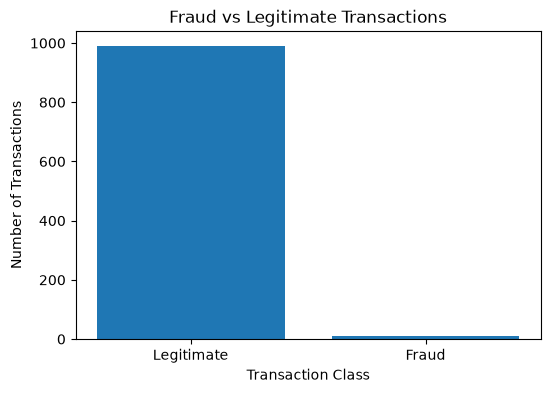

In [11]:
import matplotlib.pyplot as plt

fraud_counts = df_sample["isFraud"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Legitimate", "Fraud"], fraud_counts.values)
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

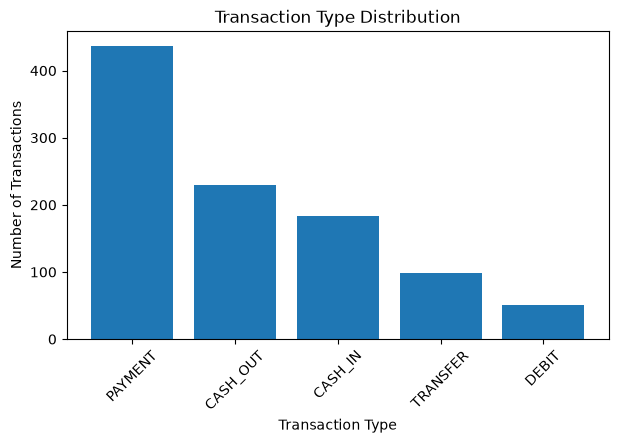

In [12]:
type_counts = df_sample["type"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

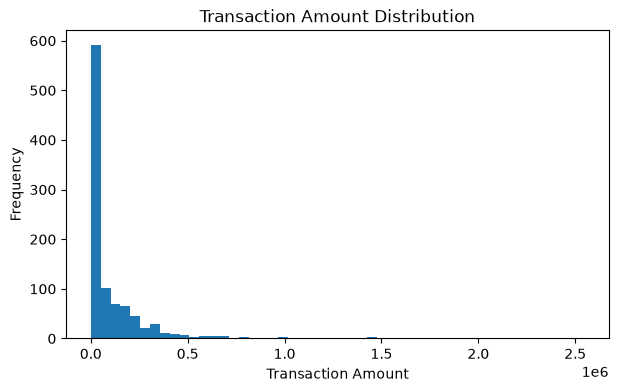

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(df_sample["amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

In [14]:
df = df_sample.copy()

print("Working dataset created.")
print("Shape:", df.shape)

Working dataset created.
Shape: (1000, 11)


In [15]:
df["sender_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["receiver_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

print(df[
    [
        "amount",
        "sender_balance_change",
        "receiver_balance_change"
    ]
].head())

     amount  sender_balance_change  receiver_balance_change
0   9839.64                9839.64                      0.0
1   1864.28                1864.28                      0.0
2    181.00                 181.00                      0.0
3    181.00                 181.00                 -21182.0
4  11668.14               11668.14                      0.0


In [16]:
df["sender_balance_error"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
).abs()

df["receiver_balance_error"] = (
    df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]
).abs()

print(df[
    [
        "amount",
        "sender_balance_error",
        "receiver_balance_error"
    ]
].head())

     amount  sender_balance_error  receiver_balance_error
0   9839.64          1.455192e-11                 9839.64
1   1864.28          1.136868e-12                 1864.28
2    181.00          0.000000e+00                  181.00
3    181.00          0.000000e+00                21363.00
4  11668.14          0.000000e+00                11668.14


In [17]:
df["hour"] = (df["step"] % 24).astype(int)
df["day"] = (df["step"] // 24).astype(int)

print(df[["step", "hour", "day"]].head())

   step  hour  day
0     1     1    0
1     1     1    0
2     1     1    0
3     1     1    0
4     1     1    0


In [18]:
df["amount_to_balance_ratio"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)

print(df[
    ["amount", "oldbalanceOrg", "amount_to_balance_ratio"]
].head())

     amount  oldbalanceOrg  amount_to_balance_ratio
0   9839.64       170136.0                 0.057834
1   1864.28        21249.0                 0.087731
2    181.00          181.0                 0.994505
3    181.00          181.0                 0.994505
4  11668.14        41554.0                 0.280788


In [19]:
new_features = [
    "sender_balance_change",
    "receiver_balance_change",
    "sender_balance_error",
    "receiver_balance_error",
    "hour",
    "day",
    "amount_to_balance_ratio"
]

print("New features created:")
print(new_features)

print("\nFeature preview:")
print(df[new_features].head())

New features created:
['sender_balance_change', 'receiver_balance_change', 'sender_balance_error', 'receiver_balance_error', 'hour', 'day', 'amount_to_balance_ratio']

Feature preview:
   sender_balance_change  receiver_balance_change  sender_balance_error  \
0                9839.64                      0.0          1.455192e-11   
1                1864.28                      0.0          1.136868e-12   
2                 181.00                      0.0          0.000000e+00   
3                 181.00                 -21182.0          0.000000e+00   
4               11668.14                      0.0          0.000000e+00   

   receiver_balance_error  hour  day  amount_to_balance_ratio  
0                 9839.64     1    0                 0.057834  
1                 1864.28     1    0                 0.087731  
2                  181.00     1    0                 0.994505  
3                21363.00     1    0                 0.994505  
4                11668.14     1    0        

In [20]:
drop_columns = [
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
]

df_model = df.drop(columns=drop_columns)

print("Remaining columns:")
print(df_model.columns.tolist())

Remaining columns:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'sender_balance_change', 'receiver_balance_change', 'sender_balance_error', 'receiver_balance_error', 'hour', 'day', 'amount_to_balance_ratio']


In [21]:
X = df_model.drop(columns=["isFraud"])
y = df_model["isFraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1000, 14)
Target shape: (1000,)

Target distribution:
isFraud
0    991
1      9
Name: count, dtype: int64


In [22]:
categorical_features = ["type"]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['type']

Numerical features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'sender_balance_change', 'receiver_balance_change', 'sender_balance_error', 'receiver_balance_error', 'hour', 'day', 'amount_to_balance_ratio']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 14)
Testing data: (200, 14)


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [25]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (800, 18)
Processed testing shape: (200, 18)


In [26]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_lr.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [27]:
y_pred = model_lr.predict(X_test_processed)
y_prob = model_lr.predict_proba(X_test_processed)[:, 1]

print("Predictions generated.")
print("First 10 predicted classes:", y_pred[:10])
print("First 10 fraud probabilities:", y_prob[:10])

Predictions generated.
First 10 predicted classes: [0 0 0 0 0 0 0 0 0 0]
First 10 fraud probabilities: [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.25181170e-17
 1.48013638e-73 1.66123993e-18 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


In [28]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       198
           1       0.67      1.00      0.80         2

    accuracy                           0.99       200
   macro avg       0.83      1.00      0.90       200
weighted avg       1.00      0.99      1.00       200


Confusion Matrix:
[[197   1]
 [  0   2]]

ROC-AUC Score:
0.9974747474747474


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Fraud Detection Metrics")
print("-----------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Fraud Detection Metrics
-----------------------
Precision : 0.6667
Recall    : 1.0000
F1-Score  : 0.8000


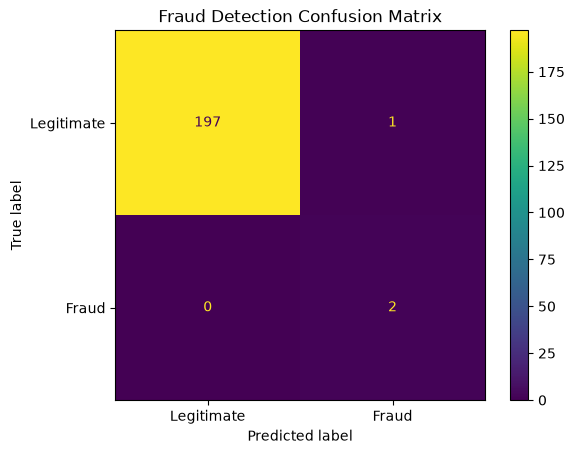

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Legitimate", "Fraud"]
)

plt.title("Fraud Detection Confusion Matrix")
plt.show()

In [31]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Fraud_Probability": y_prob
})

print(results.sort_values(
    "Fraud_Probability",
    ascending=False
).head(10))

     Actual  Predicted  Fraud_Probability
54        0          1           1.000000
73        1          1           1.000000
163       1          1           1.000000
126       0          0           0.073330
156       0          0           0.071762
195       0          0           0.069521
10        0          0           0.068551
153       0          0           0.067164
72        0          0           0.067076
60        0          0           0.065579


In [32]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_rf.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [33]:
y_pred_rf = model_rf.predict(X_test_processed)
y_prob_rf = model_rf.predict_proba(X_test_processed)[:, 1]

print("Random Forest predictions generated.")
print("First 10 predictions:", y_pred_rf[:10])
print("First 10 fraud probabilities:", y_prob_rf[:10])

Random Forest predictions generated.
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 fraud probabilities: [0.   0.   0.02 0.   0.   0.   0.   0.   0.   0.  ]


In [34]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Metrics")
print("---------------------")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

Random Forest Metrics
---------------------
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
ROC-AUC   : 1.0000


In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        rf_auc
    ]
})

comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.666667,1.0,0.8,0.997475
1,Random Forest,1.000000,1.0,1.0,1.000000


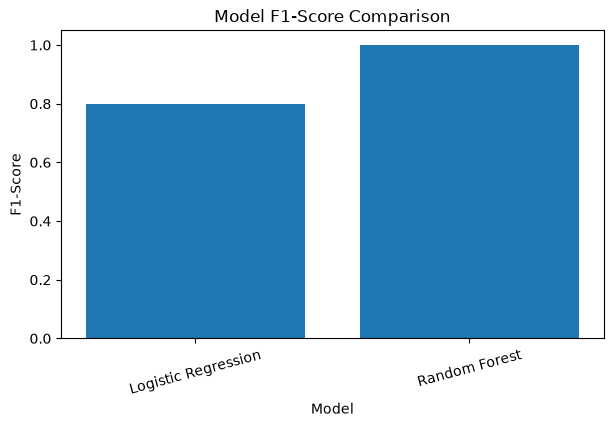

In [36]:
plt.figure(figsize=(7, 4))

plt.bar(
    comparison["Model"],
    comparison["F1-Score"]
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)
plt.show()

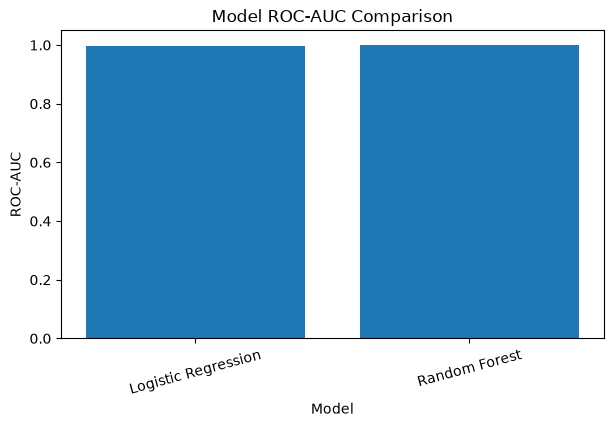

In [37]:
plt.figure(figsize=(7, 4))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=15)
plt.show()

In [39]:
chunk_size = 100000

chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    chunks.append(chunk)

df_full = pd.concat(chunks, ignore_index=True)

print("Full dataset loaded.")
print("Shape:", df_full.shape)

Full dataset loaded.
Shape: (6362620, 11)


In [40]:
print("Fraud distribution:")
print(df_full["isFraud"].value_counts())

print("\nFraud percentage:")
print(
    (df_full["isFraud"].value_counts(normalize=True) * 100)
    .round(4)
)

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


In [41]:
print("Transaction types:")
print(df_full["type"].value_counts())

Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [42]:
df_full["sender_balance_change"] = (
    df_full["oldbalanceOrg"] - df_full["newbalanceOrig"]
)

df_full["receiver_balance_change"] = (
    df_full["newbalanceDest"] - df_full["oldbalanceDest"]
)

df_full["sender_balance_error"] = (
    df_full["oldbalanceOrg"]
    - df_full["newbalanceOrig"]
    - df_full["amount"]
).abs()

df_full["receiver_balance_error"] = (
    df_full["newbalanceDest"]
    - df_full["oldbalanceDest"]
    - df_full["amount"]
).abs()

print("Balance features created.")

Balance features created.


In [43]:
df_full["hour"] = (df_full["step"] % 24).astype(int)
df_full["day"] = (df_full["step"] // 24).astype(int)

df_full["amount_to_balance_ratio"] = (
    df_full["amount"] / (df_full["oldbalanceOrg"] + 1)
)

print("Time and ratio features created.")

Time and ratio features created.


In [44]:
print("Dataset shape:", df_full.shape)

print("\nColumns:")
print(df_full.columns.tolist())

Dataset shape: (6362620, 18)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'sender_balance_change', 'receiver_balance_change', 'sender_balance_error', 'receiver_balance_error', 'hour', 'day', 'amount_to_balance_ratio']


In [45]:
drop_columns_full = [
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
]

df_model_full = df_full.drop(
    columns=drop_columns_full
)

print("Columns removed.")
print("Remaining columns:", df_model_full.shape[1])

Columns removed.
Remaining columns: 15


In [46]:
X_full = df_model_full.drop(columns=["isFraud"])
y_full = df_model_full["isFraud"]

print("Features:", X_full.shape)
print("Target:", y_full.shape)

print("\nFraud distribution:")
print(y_full.value_counts())

Features: (6362620, 14)
Target: (6362620,)

Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [47]:
from sklearn.model_selection import train_test_split

X_dev, _, y_dev, _ = train_test_split(
    X_full,
    y_full,
    train_size=500000,
    stratify=y_full,
    random_state=42
)

print("Development dataset:", X_dev.shape)
print("Development target:", y_dev.shape)

print("\nDevelopment fraud distribution:")
print(y_dev.value_counts())

Development dataset: (500000, 14)
Development target: (500000,)

Development fraud distribution:
isFraud
0    499355
1       645
Name: count, dtype: int64


In [48]:
categorical_features_full = ["type"]

numerical_features_full = [
    column
    for column in X_dev.columns
    if column not in categorical_features_full
]

print("Categorical features:")
print(categorical_features_full)

print("\nNumber of numerical features:", len(numerical_features_full))
print(numerical_features_full)

Categorical features:
['type']

Number of numerical features: 13
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'sender_balance_change', 'receiver_balance_change', 'sender_balance_error', 'receiver_balance_error', 'hour', 'day', 'amount_to_balance_ratio']


In [49]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    stratify=y_dev,
    random_state=42
)

print("Training:", X_train_full.shape)
print("Testing:", X_test_full.shape)

Training: (400000, 14)
Testing: (100000, 14)


In [50]:
preprocessor_full = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_full
        )
    ],
    remainder="passthrough"
)

print("Full-data preprocessing pipeline created.")

Full-data preprocessing pipeline created.


In [51]:
X_train_full_processed = preprocessor_full.fit_transform(
    X_train_full
)

print(
    "Processed training shape:",
    X_train_full_processed.shape
)

Processed training shape: (400000, 18)


In [52]:
X_test_full_processed = preprocessor_full.transform(
    X_test_full
)

print(
    "Processed testing shape:",
    X_test_full_processed.shape
)

Processed testing shape: (100000, 18)


In [54]:
model_rf_full = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_rf_full.fit(
    X_train_full_processed,
    y_train_full
)

print("Full Random Forest trained successfully.")

Full Random Forest trained successfully.


In [55]:
y_pred_full = model_rf_full.predict(
    X_test_full_processed
)

y_prob_full = model_rf_full.predict_proba(
    X_test_full_processed
)[:, 1]

print("Predictions generated.")

Predictions generated.


In [56]:
print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test_full,
        y_pred_full,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     99871
       Fraud       1.00      1.00      1.00       129

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



In [57]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

precision_full = precision_score(
    y_test_full,
    y_pred_full,
    zero_division=0
)

recall_full = recall_score(
    y_test_full,
    y_pred_full,
    zero_division=0
)

f1_full = f1_score(
    y_test_full,
    y_pred_full,
    zero_division=0
)

roc_auc_full = roc_auc_score(
    y_test_full,
    y_prob_full
)

pr_auc_full = average_precision_score(
    y_test_full,
    y_prob_full
)

print("Fraud Detection Metrics")
print("-----------------------")
print(f"Precision : {precision_full:.4f}")
print(f"Recall    : {recall_full:.4f}")
print(f"F1-Score  : {f1_full:.4f}")
print(f"ROC-AUC   : {roc_auc_full:.4f}")
print(f"PR-AUC     : {pr_auc_full:.4f}")

Fraud Detection Metrics
-----------------------
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
ROC-AUC   : 1.0000
PR-AUC     : 1.0000


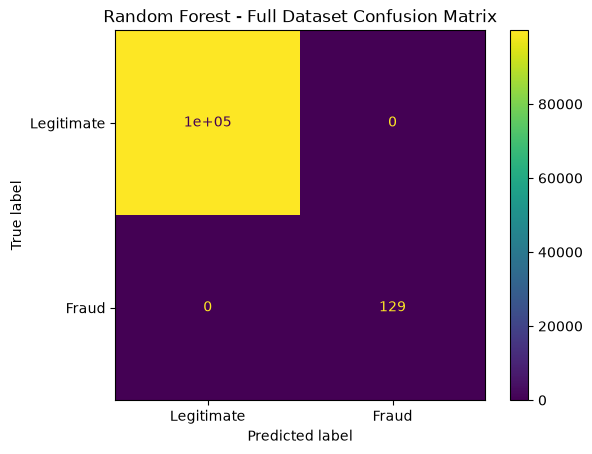

In [58]:
ConfusionMatrixDisplay.from_predictions(
    y_test_full,
    y_pred_full,
    display_labels=["Legitimate", "Fraud"]
)

plt.title("Random Forest - Full Dataset Confusion Matrix")
plt.show()

In [59]:
risk_scores = y_prob_full * 100

print("First 10 Risk Scores:")
print(risk_scores[:10])

First 10 Risk Scores:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [61]:
def get_risk_level(score):
    if score <= 30:
        return "Low"
    elif score <= 70:
        return "Medium"
    else:
        return "High"


risk_levels = [
    get_risk_level(score)
    for score in risk_scores
]

print("First 10 Risk Levels:")
print(risk_levels[:10])

First 10 Risk Levels:
['Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low']


In [62]:
prediction_results = X_test_full.copy()

prediction_results["Actual_Fraud"] = y_test_full.values
prediction_results["Fraud_Probability"] = y_prob_full
prediction_results["Risk_Score"] = risk_scores
prediction_results["Risk_Level"] = risk_levels

prediction_results.head(10)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,sender_balance_change,receiver_balance_change,sender_balance_error,receiver_balance_error,hour,day,amount_to_balance_ratio,Actual_Fraud,Fraud_Probability,Risk_Score,Risk_Level
4436454,323,CASH_OUT,52529.69,0.00,0.00,1399494.08,1452023.77,0.00,52529.69,5.252969e+04,5.820766e-11,11,13,52529.690000,0,0.0,0.0,Low
1036023,94,PAYMENT,3169.14,62.93,0.00,0.00,0.00,62.93,0.00,3.106210e+03,3.169140e+03,22,3,49.572032,0,0.0,0.0,Low
1316191,136,PAYMENT,13780.85,0.00,0.00,0.00,0.00,0.00,0.00,1.378085e+04,1.378085e+04,16,5,13780.850000,0,0.0,0.0,Low
1042349,94,CASH_IN,302646.14,365622.93,668269.07,3400326.06,3097679.92,-302646.14,-302646.14,6.052923e+05,6.052923e+05,22,3,0.827753,0,0.0,0.0,Low
2254521,187,CASH_IN,24632.22,520753.19,545385.41,66125.86,41493.64,-24632.22,-24632.22,4.926444e+04,4.926444e+04,19,7,0.047301,0,0.0,0.0,Low
1010853,46,PAYMENT,1221.23,20583.00,19361.77,0.00,0.00,1221.23,0.00,4.547474e-13,1.221230e+03,22,1,0.059329,0,0.0,0.0,Low
181079,12,PAYMENT,3370.88,566447.56,563076.67,0.00,0.00,3370.89,0.00,1.000000e-02,3.370880e+03,12,0,0.005951,0,0.0,0.0,Low
1233470,134,CASH_OUT,124416.54,0.00,0.00,1936979.65,2061396.18,0.00,124416.53,1.244165e+05,1.000000e-02,14,5,124416.540000,0,0.0,0.0,Low
1337401,137,CASH_OUT,198271.44,3493.00,0.00,0.00,198271.44,3493.00,198271.44,1.947784e+05,0.000000e+00,17,5,56.746262,0,0.0,0.0,Low
2399776,201,CASH_IN,13557.57,7294283.76,7307841.33,361302.79,347745.21,-13557.57,-13557.58,2.711514e+04,2.711515e+04,9,8,0.001859,0,0.0,0.0,Low


In [63]:
high_risk_transactions = prediction_results.sort_values(
    "Risk_Score",
    ascending=False
)

high_risk_transactions[
    [
        "type",
        "amount",
        "Fraud_Probability",
        "Risk_Score",
        "Risk_Level",
        "Actual_Fraud"
    ]
].head(10)

,type,amount,Fraud_Probability,Risk_Score,Risk_Level,Actual_Fraud
6020336,TRANSFER,1968008.53,1.0,100.0,High,1
6064979,CASH_OUT,7041719.54,1.0,100.0,High,1
6187838,TRANSFER,176626.77,1.0,100.0,High,1
4012372,TRANSFER,677503.25,1.0,100.0,High,1
1059581,CASH_OUT,1409248.64,1.0,100.0,High,1
6020352,TRANSFER,86111.65,1.0,100.0,High,1
1931864,CASH_OUT,6302888.93,1.0,100.0,High,1
2982687,TRANSFER,261331.82,1.0,100.0,High,1
2539531,CASH_OUT,5903046.38,1.0,100.0,High,1
6260424,TRANSFER,136331.05,1.0,100.0,High,1


In [64]:
print("Risk Level Distribution:")
print(prediction_results["Risk_Level"].value_counts())

Risk Level Distribution:
Risk_Level
Low       99870
High        129
Medium        1
Name: count, dtype: int64


In [65]:
risk_fraud_table = pd.crosstab(
    prediction_results["Risk_Level"],
    prediction_results["Actual_Fraud"]
)

print(risk_fraud_table)

Actual_Fraud      0    1
Risk_Level              
High              0  129
Low           99870    0
Medium            1    0


In [66]:
fraud_rate_by_risk = (
    prediction_results
    .groupby("Risk_Level")["Actual_Fraud"]
    .mean()
    .mul(100)
    .round(2)
)

print("Actual fraud rate by risk level:")
print(fraud_rate_by_risk)

Actual fraud rate by risk level:
Risk_Level
High      100.0
Low         0.0
Medium      0.0
Name: Actual_Fraud, dtype: float64


In [67]:
avg_probability = (
    prediction_results
    .groupby("Risk_Level")["Fraud_Probability"]
    .mean()
    .round(4)
)

print("Average predicted fraud probability:")
print(avg_probability)

Average predicted fraud probability:
Risk_Level
High      0.9895
Low       0.0000
Medium    0.4533
Name: Fraud_Probability, dtype: float64


In [68]:
actual_fraud = prediction_results[
    prediction_results["Actual_Fraud"] == 1
]

print("Actual fraud transactions:", len(actual_fraud))

actual_fraud[
    [
        "type",
        "amount",
        "Fraud_Probability",
        "Risk_Score",
        "Risk_Level"
    ]
].sort_values(
    "Risk_Score",
    ascending=False
).head(20)

Actual fraud transactions: 129


,type,amount,Fraud_Probability,Risk_Score,Risk_Level
4154975,CASH_OUT,5614246.07,1.0,100.0,High
1030692,CASH_OUT,351912.04,1.0,100.0,High
6030111,CASH_OUT,417620.07,1.0,100.0,High
6154176,TRANSFER,400276.72,1.0,100.0,High
6343983,TRANSFER,466218.08,1.0,100.0,High
6362594,TRANSFER,144945.34,1.0,100.0,High
1325512,CASH_OUT,417217.89,1.0,100.0,High
4388762,TRANSFER,247455.25,1.0,100.0,High
6362426,TRANSFER,276298.49,1.0,100.0,High
1511346,TRANSFER,172510.95,1.0,100.0,High


In [69]:
prediction_results[
    [
        "type",
        "amount",
        "Fraud_Probability",
        "Risk_Score",
        "Risk_Level",
        "Actual_Fraud"
    ]
].sort_values(
    "Risk_Score",
    ascending=False
).head(20)

,type,amount,Fraud_Probability,Risk_Score,Risk_Level,Actual_Fraud
6020336,TRANSFER,1968008.53,1.0,100.0,High,1
6064979,CASH_OUT,7041719.54,1.0,100.0,High,1
6187838,TRANSFER,176626.77,1.0,100.0,High,1
4012372,TRANSFER,677503.25,1.0,100.0,High,1
1059581,CASH_OUT,1409248.64,1.0,100.0,High,1
6020352,TRANSFER,86111.65,1.0,100.0,High,1
1931864,CASH_OUT,6302888.93,1.0,100.0,High,1
2982687,TRANSFER,261331.82,1.0,100.0,High,1
2539531,CASH_OUT,5903046.38,1.0,100.0,High,1
6260424,TRANSFER,136331.05,1.0,100.0,High,1


In [70]:
explanation_data = prediction_results.copy()

explanation_data["Large_Amount"] = (
    explanation_data["amount"]
    > df_full["amount"].quantile(0.95)
)

explanation_data["High_Amount_Ratio"] = (
    explanation_data["amount_to_balance_ratio"] > 0.8
)

explanation_data["Sender_Balance_Anomaly"] = (
    explanation_data["sender_balance_error"] > 1
)

explanation_data["Receiver_Balance_Anomaly"] = (
    explanation_data["receiver_balance_error"] > 1
)

print("Explanation features created.")

Explanation features created.


In [72]:
def generate_explanation(row):
    reasons = []

    if row["Large_Amount"]:
        reasons.append("Unusually large transaction amount")

    if row["High_Amount_Ratio"]:
        reasons.append("Transaction is large relative to sender balance")

    if row["Sender_Balance_Anomaly"]:
        reasons.append("Sender balance movement is unusual")

    if row["Receiver_Balance_Anomaly"]:
        reasons.append("Receiver balance movement is unusual")

    if not reasons:
        reasons.append("No major risk indicators detected")

    return reasons

In [73]:
explanation_data["Risk_Reasons"] = explanation_data.apply(
    generate_explanation,
    axis=1
)

print(
    explanation_data[
        [
            "type",
            "amount",
            "Risk_Score",
            "Risk_Level",
            "Risk_Reasons"
        ]
    ].head(10)
)

             type     amount  Risk_Score Risk_Level  \
4436454  CASH_OUT   52529.69         0.0        Low   
1036023   PAYMENT    3169.14         0.0        Low   
1316191   PAYMENT   13780.85         0.0        Low   
1042349   CASH_IN  302646.14         0.0        Low   
2254521   CASH_IN   24632.22         0.0        Low   
1010853   PAYMENT    1221.23         0.0        Low   
181079    PAYMENT    3370.88         0.0        Low   
1233470  CASH_OUT  124416.54         0.0        Low   
1337401  CASH_OUT  198271.44         0.0        Low   
2399776   CASH_IN   13557.57         0.0        Low   

                                              Risk_Reasons  
4436454  [Transaction is large relative to sender balan...  
1036023  [Transaction is large relative to sender balan...  
1316191  [Transaction is large relative to sender balan...  
1042349  [Transaction is large relative to sender balan...  
2254521  [Sender balance movement is unusual, Receiver ...  
1010853             [Receive

In [74]:
high_risk_explanations = explanation_data[
    explanation_data["Risk_Level"] == "High"
].sort_values(
    "Risk_Score",
    ascending=False
)

high_risk_explanations[
    [
        "type",
        "amount",
        "Fraud_Probability",
        "Risk_Score",
        "Risk_Level",
        "Risk_Reasons"
    ]
].head(20)

,type,amount,Fraud_Probability,Risk_Score,Risk_Level,Risk_Reasons
4154975,CASH_OUT,5614246.07,1.0,100.0,High,"[Unusually large transaction amount, Transacti..."
1030692,CASH_OUT,351912.04,1.0,100.0,High,[Transaction is large relative to sender balance]
6030111,CASH_OUT,417620.07,1.0,100.0,High,[Transaction is large relative to sender balance]
6154176,TRANSFER,400276.72,1.0,100.0,High,[Transaction is large relative to sender balan...
6343983,TRANSFER,466218.08,1.0,100.0,High,[Transaction is large relative to sender balan...
6362594,TRANSFER,144945.34,1.0,100.0,High,[Transaction is large relative to sender balan...
1325512,CASH_OUT,417217.89,1.0,100.0,High,[Transaction is large relative to sender balance]
4388762,TRANSFER,247455.25,1.0,100.0,High,[Transaction is large relative to sender balan...
6362426,TRANSFER,276298.49,1.0,100.0,High,[Transaction is large relative to sender balan...
1511346,TRANSFER,172510.95,1.0,100.0,High,[Transaction is large relative to sender balan...


In [75]:
from collections import Counter

all_reasons = []

for reasons in explanation_data["Risk_Reasons"]:
    all_reasons.extend(reasons)

reason_counts = Counter(all_reasons)

print("Most common risk indicators:")

for reason, count in reason_counts.most_common():
    print(f"{reason}: {count}")

Most common risk indicators:
Sender balance movement is unusual: 78791
Transaction is large relative to sender balance: 66190
Receiver balance movement is unusual: 60047
Unusually large transaction amount: 5011
No major risk indicators detected: 3689


In [76]:
%pip install shap

  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   -- ------------------------------------- 3.1/43.0 MB 16.2 MB/s eta 0:00:03
   ----- ---------------------------------- 6.3/43.0 MB 15.2 MB/s eta 0:00:03
   -------- ------------------------------- 8.9/43.0 MB 14.3 MB/s eta 0:00:03
   ---------- ----------------------------- 11.8/43.0 MB 13.7 MB/s eta 0:00:03
   ------------- -------------------------- 14.2/43.0 MB 13.5 MB/s eta 0:00:03
   --------------- ------------------------ 16.8/43.0 MB 13.3 MB/s eta 0:00:02
   ------------------ --------------------- 19.7/43.0 MB 13.1 MB/s eta 0:00:02
   -------------------- ------------------- 22.0/43.0 MB 13.0 MB/s eta 0:00:02
   ---------------------- ----------------- 24.6/43.0 MB 13.0 MB/s eta 0:00:02
   ------------------------- -------------- 27.3/43.0 MB 12.9 MB/s eta 0:00:02
   --------------------------- -

In [77]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [78]:
shap_sample_size = 500

X_shap = X_test_full_processed[:shap_sample_size]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (500, 18)


In [79]:
explainer = shap.TreeExplainer(model_rf_full)

print("SHAP explainer created.")

SHAP explainer created.


In [80]:
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated.")

SHAP values calculated.


In [84]:
print("Type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))
    print("SHAP array shape:", shap_values[1].shape)
else:
    print("SHAP array shape:", shap_values.shape)

print("Number of feature names:", len(feature_names))

Type: <class 'numpy.ndarray'>
SHAP array shape: (500, 18, 2)
Number of feature names: 18


In [85]:
if isinstance(shap_values, list):
    shap_array = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_array = shap_values[:, :, 1]
    else:
        shap_array = shap_values

print("Final SHAP shape:", shap_array.shape)
print("Number of features:", len(feature_names))

Final SHAP shape: (500, 18)
Number of features: 18


In [86]:
mean_abs_shap = np.abs(shap_array).mean(axis=0)

print("SHAP importance length:", len(mean_abs_shap))
print("Feature names length:", len(feature_names))

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_abs_shap
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

SHAP importance length: 18
Feature names length: 18


,Feature,Importance
13,remainder__sender_balance_error,0.152673
17,remainder__amount_to_balance_ratio,0.138950
8,remainder__newbalanceOrig,0.083597
11,remainder__sender_balance_change,0.068218
3,categorical__type_PAYMENT,0.027420
7,remainder__oldbalanceOrg,0.021862
6,remainder__amount,0.019845
4,categorical__type_TRANSFER,0.015249
0,categorical__type_CASH_IN,0.007799
10,remainder__newbalanceDest,0.007643


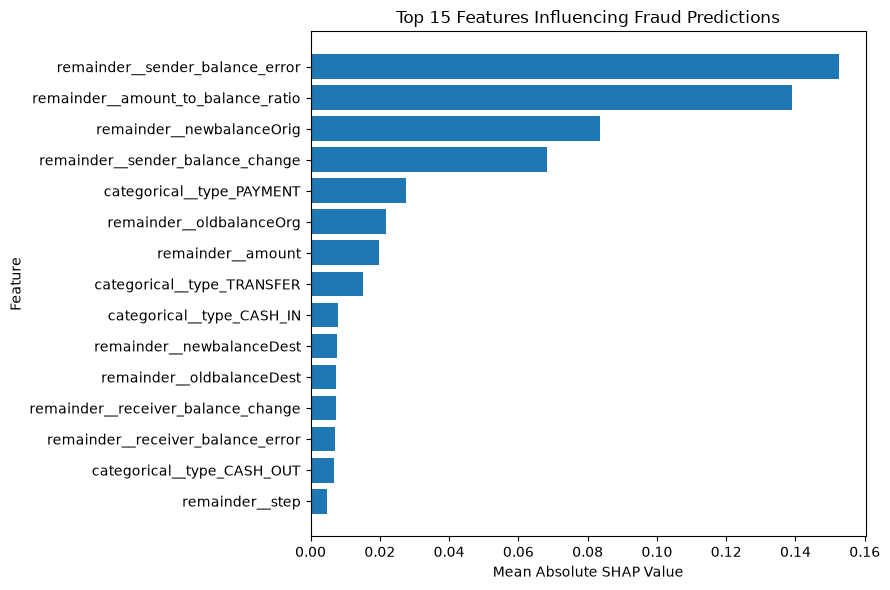

In [87]:
top_features = feature_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Features Influencing Fraud Predictions")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [88]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready.")

Models folder ready.


In [89]:
model_path = "../models/fraud_model.pkl"

joblib.dump(model_rf_full, model_path)

print("Model saved to:", model_path)

Model saved to: ../models/fraud_model.pkl


In [90]:
preprocessor_path = "../models/preprocessor.pkl"

joblib.dump(preprocessor_full, preprocessor_path)

print("Preprocessor saved to:", preprocessor_path)

Preprocessor saved to: ../models/preprocessor.pkl


In [91]:
feature_names_path = "../models/feature_names.pkl"

joblib.dump(feature_names, feature_names_path)

print("Feature names saved to:", feature_names_path)

Feature names saved to: ../models/feature_names.pkl


In [92]:
model_files = os.listdir("../models")

print("Files inside models folder:")
for file in model_files:
    print("-", file)

Files inside models folder:
- feature_names.pkl
- fraud_model.pkl
- preprocessor.pkl


In [93]:
import joblib
import pandas as pd
import numpy as np

loaded_model = joblib.load("../models/fraud_model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model and preprocessor loaded successfully.")

Model and preprocessor loaded successfully.


In [94]:
def predict_transaction(transaction):
    
    transaction_df = pd.DataFrame([transaction])
    
    # Apply the same preprocessing used during training
    transaction_processed = loaded_preprocessor.transform(transaction_df)
    
    # Fraud probability
    fraud_probability = loaded_model.predict_proba(
        transaction_processed
    )[0, 1]
    
    # Risk score
    risk_score = fraud_probability * 100
    
    # Risk level
    if risk_score <= 30:
        risk_level = "Low"
    elif risk_score <= 70:
        risk_level = "Medium"
    else:
        risk_level = "High"
    
    return {
        "fraud_probability": fraud_probability,
        "risk_score": risk_score,
        "risk_level": risk_level
    }

print("Prediction function created.")

Prediction function created.


In [95]:
test_transaction = {
    "step": 100,
    "type": "TRANSFER",
    "amount": 50000,
    "oldbalanceOrg": 60000,
    "newbalanceOrig": 10000,
    "oldbalanceDest": 0,
    "newbalanceDest": 50000,
    "sender_balance_change": 50000,
    "receiver_balance_change": 50000,
    "sender_balance_error": 0,
    "receiver_balance_error": 0,
    "hour": 4,
    "day": 4,
    "amount_to_balance_ratio": 50000 / (60000 + 1)
}

print(test_transaction)

{'step': 100, 'type': 'TRANSFER', 'amount': 50000, 'oldbalanceOrg': 60000, 'newbalanceOrig': 10000, 'oldbalanceDest': 0, 'newbalanceDest': 50000, 'sender_balance_change': 50000, 'receiver_balance_change': 50000, 'sender_balance_error': 0, 'receiver_balance_error': 0, 'hour': 4, 'day': 4, 'amount_to_balance_ratio': 0.8333194446759221}


In [96]:
result = predict_transaction(test_transaction)

print("Fraud Probability:", round(result["fraud_probability"] * 100, 2), "%")
print("Risk Score:", round(result["risk_score"], 2), "/ 100")
print("Risk Level:", result["risk_level"])

Fraud Probability: 0.67 %
Risk Score: 0.67 / 100
Risk Level: Low


In [97]:
result_df = pd.DataFrame([{
    "Fraud Probability (%)": round(result["fraud_probability"] * 100, 2),
    "Risk Score": round(result["risk_score"], 2),
    "Risk Level": result["risk_level"]
}])

result_df

,Fraud Probability (%),Risk Score,Risk Level
0,0.67,0.67,Low


In [98]:
def explain_transaction(transaction):
    
    reasons = []
    
    if transaction["amount"] > df_full["amount"].quantile(0.95):
        reasons.append("Unusually large transaction amount")
    
    if transaction["amount_to_balance_ratio"] > 0.8:
        reasons.append("Transaction is large relative to sender balance")
    
    if transaction["sender_balance_error"] > 1:
        reasons.append("Sender balance movement is unusual")
    
    if transaction["receiver_balance_error"] > 1:
        reasons.append("Receiver balance movement is unusual")
    
    if not reasons:
        reasons.append("No major risk indicators detected")
    
    return reasons

In [99]:
def predict_transaction(transaction):
    
    transaction_df = pd.DataFrame([transaction])
    
    transaction_processed = loaded_preprocessor.transform(
        transaction_df
    )
    
    fraud_probability = loaded_model.predict_proba(
        transaction_processed
    )[0, 1]
    
    risk_score = fraud_probability * 100
    
    if risk_score <= 30:
        risk_level = "Low"
    elif risk_score <= 70:
        risk_level = "Medium"
    else:
        risk_level = "High"
    
    risk_reasons = explain_transaction(transaction)
    
    return {
        "fraud_probability": fraud_probability,
        "risk_score": risk_score,
        "risk_level": risk_level,
        "risk_reasons": risk_reasons
    }

print("Updated prediction function created.")

Updated prediction function created.


In [100]:
result = predict_transaction(test_transaction)

print("Fraud Probability:", 
      round(result["fraud_probability"] * 100, 2), "%")

print("Risk Score:", 
      round(result["risk_score"], 2), "/ 100")

print("Risk Level:", 
      result["risk_level"])

print("\nRisk Reasons:")

for reason in result["risk_reasons"]:
    print("-", reason)

Fraud Probability: 0.67 %
Risk Score: 0.67 / 100
Risk Level: Low

Risk Reasons:
- Transaction is large relative to sender balance


In [101]:
result_df = pd.DataFrame([{
    "Fraud Probability (%)": round(
        result["fraud_probability"] * 100, 2
    ),
    "Risk Score": round(result["risk_score"], 2),
    "Risk Level": result["risk_level"]
}])

result_df

,Fraud Probability (%),Risk Score,Risk Level
0,0.67,0.67,Low


In [102]:
high_risk_transaction = {
    "step": 100,
    "type": "TRANSFER",
    "amount": 95000,
    "oldbalanceOrg": 100000,
    "newbalanceOrig": 5000,
    "oldbalanceDest": 0,
    "newbalanceDest": 95000,
    "sender_balance_change": 95000,
    "receiver_balance_change": 95000,
    "sender_balance_error": 0,
    "receiver_balance_error": 0,
    "hour": 4,
    "day": 4,
    "amount_to_balance_ratio": 95000 / (100000 + 1)
}

high_risk_result = predict_transaction(high_risk_transaction)

print("Fraud Probability:",
      round(high_risk_result["fraud_probability"] * 100, 2), "%")

print("Risk Score:",
      round(high_risk_result["risk_score"], 2), "/ 100")

print("Risk Level:",
      high_risk_result["risk_level"])

print("\nRisk Reasons:")

for reason in high_risk_result["risk_reasons"]:
    print("-", reason)

Fraud Probability: 1.33 %
Risk Score: 1.33 / 100
Risk Level: Low

Risk Reasons:
- Transaction is large relative to sender balance


In [103]:
probability_percent = y_prob_full * 100

print("Minimum:", round(probability_percent.min(), 4))
print("25th percentile:", round(np.percentile(probability_percent, 25), 4))
print("Median:", round(np.median(probability_percent), 4))
print("75th percentile:", round(np.percentile(probability_percent, 75), 4))
print("95th percentile:", round(np.percentile(probability_percent, 95), 4))
print("99th percentile:", round(np.percentile(probability_percent, 99), 4))
print("Maximum:", round(probability_percent.max(), 4))

Minimum: 0.0
25th percentile: 0.0
Median: 0.0
75th percentile: 0.0
95th percentile: 0.0
99th percentile: 0.0
Maximum: 100.0


In [104]:
fraud_probabilities = y_prob_full[y_test_full.values == 1] * 100

print("Actual fraud transactions:", len(fraud_probabilities))

print("Minimum fraud probability:",
      round(fraud_probabilities.min(), 2), "%")

print("Median fraud probability:",
      round(np.median(fraud_probabilities), 2), "%")

print("75th percentile:",
      round(np.percentile(fraud_probabilities, 75), 2), "%")

print("Maximum fraud probability:",
      round(fraud_probabilities.max(), 2), "%")

Actual fraud transactions: 129
Minimum fraud probability: 89.33 %
Median fraud probability: 100.0 %
75th percentile: 100.0 %
Maximum fraud probability: 100.0 %


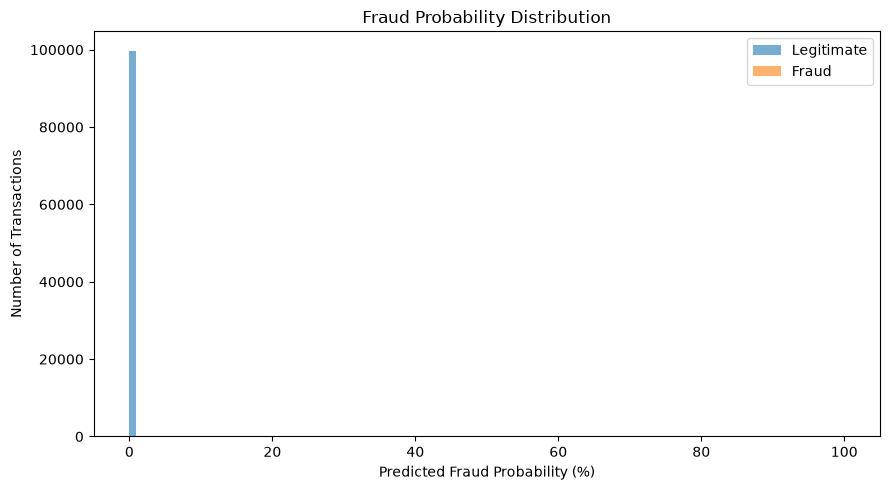

In [105]:
plt.figure(figsize=(9, 5))

plt.hist(
    y_prob_full[y_test_full.values == 0] * 100,
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    y_prob_full[y_test_full.values == 1] * 100,
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Predicted Fraud Probability (%)")
plt.ylabel("Number of Transactions")
plt.title("Fraud Probability Distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [106]:
thresholds = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50]

for threshold in thresholds:
    
    predicted_fraud = (
        y_prob_full >= threshold
    ).astype(int)
    
    precision = precision_score(
        y_test_full,
        predicted_fraud,
        zero_division=0
    )
    
    recall = recall_score(
        y_test_full,
        predicted_fraud,
        zero_division=0
    )
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.01 | Precision: 0.537 | Recall: 1.000
Threshold: 0.02 | Precision: 0.679 | Recall: 1.000
Threshold: 0.05 | Precision: 0.866 | Recall: 1.000
Threshold: 0.10 | Precision: 0.949 | Recall: 1.000
Threshold: 0.20 | Precision: 0.977 | Recall: 1.000
Threshold: 0.50 | Precision: 1.000 | Recall: 1.000


In [107]:
# These are policy thresholds, not model probabilities.
# They can be changed later based on business requirements.

LOW_RISK_THRESHOLD = 5
HIGH_RISK_THRESHOLD = 50

def get_risk_level(score):
    
    if score < LOW_RISK_THRESHOLD:
        return "Low"
    
    elif score < HIGH_RISK_THRESHOLD:
        return "Medium"
    
    else:
        return "High"

print("Risk policy:")
print("0 -", LOW_RISK_THRESHOLD, ": Low")
print(LOW_RISK_THRESHOLD, "-", HIGH_RISK_THRESHOLD, ": Medium")
print(HIGH_RISK_THRESHOLD, "- 100: High")

Risk policy:
0 - 5 : Low
5 - 50 : Medium
50 - 100: High


In [108]:
def predict_transaction(transaction):
    
    transaction_df = pd.DataFrame([transaction])
    
    transaction_processed = loaded_preprocessor.transform(
        transaction_df
    )
    
    fraud_probability = loaded_model.predict_proba(
        transaction_processed
    )[0, 1]
    
    risk_score = fraud_probability * 100
    
    risk_level = get_risk_level(risk_score)
    
    risk_reasons = explain_transaction(transaction)
    
    return {
        "fraud_probability": fraud_probability,
        "risk_score": risk_score,
        "risk_level": risk_level,
        "risk_reasons": risk_reasons
    }

print("Prediction function updated.")

Prediction function updated.


In [109]:
result = predict_transaction(test_transaction)

print("Fraud Probability:",
      round(result["fraud_probability"] * 100, 2), "%")

print("Risk Score:",
      round(result["risk_score"], 2), "/ 100")

print("Risk Level:",
      result["risk_level"])

print("\nRisk Reasons:")

for reason in result["risk_reasons"]:
    print("-", reason)

Fraud Probability: 0.67 %
Risk Score: 0.67 / 100
Risk Level: Low

Risk Reasons:
- Transaction is large relative to sender balance


In [110]:
risk_policy = {
    "low_risk_threshold": LOW_RISK_THRESHOLD,
    "high_risk_threshold": HIGH_RISK_THRESHOLD
}

joblib.dump(
    risk_policy,
    "../models/risk_policy.pkl"
)

print("Risk policy saved successfully.")

Risk policy saved successfully.


In [111]:
model_metadata = {
    "model_type": "Random Forest Classifier",
    "n_estimators": 150,
    "training_sample_size": 500000,
    "test_sample_size": 100000,
    "features": list(X_full.columns),
    "categorical_features": categorical_features_full,
    "target": "isFraud",
    "risk_score_range": "0-100",
    "risk_policy": risk_policy
}

joblib.dump(
    model_metadata,
    "../models/model_metadata.pkl"
)

print("Model metadata saved.")

Model metadata saved.


In [112]:
print("Files inside models folder:\n")

for file in sorted(os.listdir("../models")):
    file_path = os.path.join("../models", file)
    
    size_kb = os.path.getsize(file_path) / 1024
    
    print(f"{file:<25} {size_kb:,.1f} KB")

Files inside models folder:

feature_names.pkl         0.9 KB
fraud_model.pkl           4,019.3 KB
model_metadata.pkl        0.5 KB
preprocessor.pkl          2.8 KB
risk_policy.pkl           0.1 KB


In [113]:
risk_policy = {
    "low_risk_threshold": LOW_RISK_THRESHOLD,
    "high_risk_threshold": HIGH_RISK_THRESHOLD
}

joblib.dump(
    risk_policy,
    "../models/risk_policy.pkl"
)

print("Risk policy saved successfully.")

Risk policy saved successfully.


In [114]:
loaded_risk_policy = joblib.load(
    "../models/risk_policy.pkl"
)

print("Loaded risk policy:")
print(loaded_risk_policy)

Loaded risk policy:
{'low_risk_threshold': 5, 'high_risk_threshold': 50}


In [115]:
print("Final model files:\n")

for file in sorted(os.listdir("../models")):
    print("-", file)

Final model files:

- feature_names.pkl
- fraud_model.pkl
- model_metadata.pkl
- preprocessor.pkl
- risk_policy.pkl


In [116]:
model_check = joblib.load("../models/fraud_model.pkl")
preprocessor_check = joblib.load("../models/preprocessor.pkl")

processed_check = preprocessor_check.transform(
    pd.DataFrame([test_transaction])
)

check_probability = model_check.predict_proba(
    processed_check
)[0, 1]

print(
    "Saved model prediction:",
    round(check_probability * 100, 2),
    "%"
)

Saved model prediction: 0.67 %


In [117]:
required_files = [
    "fraud_model.pkl",
    "preprocessor.pkl",
    "feature_names.pkl",
    "model_metadata.pkl",
    "risk_policy.pkl"
]

all_present = all(
    os.path.exists("../models/" + file)
    for file in required_files
)

print("All model files ready:", all_present)

if all_present:
    print("Ready to build FastAPI.")

All model files ready: True
Ready to build FastAPI.


In [118]:
max_probability = y_prob_full.max() * 100

print(
    "Maximum predicted fraud probability:",
    round(max_probability, 2),
    "%"
)

Maximum predicted fraud probability: 100.0 %


In [119]:
top_indices = np.argsort(y_prob_full)[-20:][::-1]

top_risk = prediction_results.iloc[top_indices].copy()

top_risk[
    [
        "type",
        "amount",
        "Fraud_Probability",
        "Risk_Score",
        "Risk_Level",
        "Actual_Fraud"
    ]
]

,type,amount,Fraud_Probability,Risk_Score,Risk_Level,Actual_Fraud
6009595,TRANSFER,10000000.00,1.0,100.0,High,1
6020341,CASH_OUT,4640633.37,1.0,100.0,High,1
6362594,TRANSFER,144945.34,1.0,100.0,High,1
6343983,TRANSFER,466218.08,1.0,100.0,High,1
6154176,TRANSFER,400276.72,1.0,100.0,High,1
6362453,CASH_OUT,10000000.00,1.0,100.0,High,1
1030385,TRANSFER,581421.85,1.0,100.0,High,1
6020336,TRANSFER,1968008.53,1.0,100.0,High,1
6030111,CASH_OUT,417620.07,1.0,100.0,High,1
10218,TRANSFER,21729.00,1.0,100.0,High,1


In [120]:
actual_fraud_mask = (
    y_test_full.values == 1
)

fraud_probabilities = y_prob_full[
    actual_fraud_mask
] * 100

print(
    "Number of actual frauds in test set:",
    len(fraud_probabilities)
)

print(
    "Highest probability assigned to an actual fraud:",
    round(
        fraud_probabilities.max(),
        2
    ),
    "%"
)

Number of actual frauds in test set: 129
Highest probability assigned to an actual fraud: 100.0 %


In [121]:
print("Actual fraud probability statistics:\n")

print(
    "Minimum:",
    round(fraud_probabilities.min(), 2),
    "%"
)

print(
    "Median:",
    round(np.median(fraud_probabilities), 2),
    "%"
)

print(
    "75th percentile:",
    round(
        np.percentile(fraud_probabilities, 75),
        2
    ),
    "%"
)

print(
    "90th percentile:",
    round(
        np.percentile(fraud_probabilities, 90),
        2
    ),
    "%"
)

print(
    "Maximum:",
    round(fraud_probabilities.max(), 2),
    "%"
)

Actual fraud probability statistics:

Minimum: 89.33 %
Median: 100.0 %
75th percentile: 100.0 %
90th percentile: 100.0 %
Maximum: 100.0 %


In [122]:
fraud_test_indices = np.where(
    y_test_full.values == 1
)[0]

best_fraud_position = fraud_test_indices[
    np.argmax(
        y_prob_full[fraud_test_indices]
    )
]

best_fraud_transaction = X_test_full.iloc[
    best_fraud_position
].copy()

best_fraud_probability = (
    y_prob_full[best_fraud_position] * 100
)

print(
    "Highest-probability actual fraud:",
    round(
        best_fraud_probability,
        2
    ),
    "%"
)

print("\nTransaction:")
print(best_fraud_transaction)

Highest-probability actual fraud: 100.0 %

Transaction:
step                              303
type                         CASH_OUT
amount                     5614246.07
oldbalanceOrg              5614246.07
newbalanceOrig                    0.0
oldbalanceDest                    0.0
newbalanceDest             5614246.07
sender_balance_change      5614246.07
receiver_balance_change    5614246.07
sender_balance_error              0.0
receiver_balance_error            0.0
hour                               15
day                                12
amount_to_balance_ratio           1.0
Name: 4154975, dtype: object


In [123]:
fraud_positions = np.where(
    y_test_full.values == 1
)[0]

best_position = fraud_positions[
    np.argmax(
        y_prob_full[fraud_positions]
    )
]

best_fraud_transaction = X_test_full.iloc[
    best_position
].copy()

best_probability = y_prob_full[
    best_position
] * 100

print(
    "Model probability for this actual fraud:",
    round(best_probability, 2),
    "%"
)

print("\nTransaction:")
print(best_fraud_transaction)

Model probability for this actual fraud: 100.0 %

Transaction:
step                              303
type                         CASH_OUT
amount                     5614246.07
oldbalanceOrg              5614246.07
newbalanceOrig                    0.0
oldbalanceDest                    0.0
newbalanceDest             5614246.07
sender_balance_change      5614246.07
receiver_balance_change    5614246.07
sender_balance_error              0.0
receiver_balance_error            0.0
hour                               15
day                                12
amount_to_balance_ratio           1.0
Name: 4154975, dtype: object


In [124]:
fraud_api_transaction = {
    "step": float(best_fraud_transaction["step"]),
    "type": best_fraud_transaction["type"],
    "amount": float(best_fraud_transaction["amount"]),
    "oldbalanceOrg": float(best_fraud_transaction["oldbalanceOrg"]),
    "newbalanceOrig": float(best_fraud_transaction["newbalanceOrig"]),
    "oldbalanceDest": float(best_fraud_transaction["oldbalanceDest"]),
    "newbalanceDest": float(best_fraud_transaction["newbalanceDest"]),
    "sender_balance_change": float(
        best_fraud_transaction["sender_balance_change"]
    ),
    "receiver_balance_change": float(
        best_fraud_transaction["receiver_balance_change"]
    ),
    "sender_balance_error": float(
        best_fraud_transaction["sender_balance_error"]
    ),
    "receiver_balance_error": float(
        best_fraud_transaction["receiver_balance_error"]
    ),
    "hour": int(best_fraud_transaction["hour"]),
    "day": int(best_fraud_transaction["day"]),
    "amount_to_balance_ratio": float(
        best_fraud_transaction["amount_to_balance_ratio"]
    )
}

print("API transaction created.")

API transaction created.


In [125]:
import json

print(
    json.dumps(
        fraud_api_transaction,
        indent=2
    )
)

{
  "step": 303.0,
  "type": "CASH_OUT",
  "amount": 5614246.07,
  "oldbalanceOrg": 5614246.07,
  "newbalanceOrig": 0.0,
  "oldbalanceDest": 0.0,
  "newbalanceDest": 5614246.07,
  "sender_balance_change": 5614246.07,
  "receiver_balance_change": 5614246.07,
  "sender_balance_error": 0.0,
  "receiver_balance_error": 0.0,
  "hour": 15,
  "day": 12,
  "amount_to_balance_ratio": 0.9999998218817256
}


In [126]:
fraud_result = predict_transaction(
    fraud_api_transaction
)

print(
    "Fraud Probability:",
    round(
        fraud_result["fraud_probability"] * 100,
        2
    ),
    "%"
)

print(
    "Risk Score:",
    round(
        fraud_result["risk_score"],
        2
    )
)

print(
    "Risk Level:",
    fraud_result["risk_level"]
)

print("\nRisk Reasons:")

for reason in fraud_result["risk_reasons"]:
    print("-", reason)

Fraud Probability: 100.0 %
Risk Score: 100.0
Risk Level: High

Risk Reasons:
- Unusually large transaction amount
- Transaction is large relative to sender balance


In [127]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_metrics = {
    "precision": float(precision_full),
    "recall": float(recall_full),
    "f1_score": float(f1_full),
    "roc_auc": float(roc_auc_full),
    "pr_auc": float(pr_auc_full)
}

print(model_metrics)

{'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0, 'roc_auc': 1.0, 'pr_auc': 1.0}


In [128]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_full,
    y_pred_full
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[99871     0]
 [    0   129]]


In [129]:
joblib.dump(
    model_metrics,
    "../models/model_metrics.pkl"
)

joblib.dump(
    cm,
    "../models/confusion_matrix.pkl"
)

print("Model metrics saved.")

Model metrics saved.


In [130]:
print("Saved files:")

for file in sorted(os.listdir("../models")):
    print("-", file)

Saved files:
- confusion_matrix.pkl
- feature_names.pkl
- fraud_model.pkl
- model_metadata.pkl
- model_metrics.pkl
- preprocessor.pkl
- risk_policy.pkl


In [131]:
loaded_metrics = joblib.load(
    "../models/model_metrics.pkl"
)

print("Saved Model Metrics:")
print()

for metric, value in loaded_metrics.items():
    print(
        f"{metric}: {value:.4f}"
    )

Saved Model Metrics:

precision: 1.0000
recall: 1.0000
f1_score: 1.0000
roc_auc: 1.0000
pr_auc: 1.0000


In [132]:
print("Top 15 SHAP Features:\n")
feature_importance.head(15)

Top 15 SHAP Features:



,Feature,Importance
13,remainder__sender_balance_error,0.152673
17,remainder__amount_to_balance_ratio,0.138950
8,remainder__newbalanceOrig,0.083597
11,remainder__sender_balance_change,0.068218
3,categorical__type_PAYMENT,0.027420
7,remainder__oldbalanceOrg,0.021862
6,remainder__amount,0.019845
4,categorical__type_TRANSFER,0.015249
0,categorical__type_CASH_IN,0.007799
10,remainder__newbalanceDest,0.007643


In [133]:
shap_importance_path = "../models/shap_feature_importance.csv"

feature_importance.to_csv(
    shap_importance_path,
    index=False
)

print("SHAP feature importance saved to:")
print(shap_importance_path)

SHAP feature importance saved to:
../models/shap_feature_importance.csv


In [134]:
top_15_shap = feature_importance.head(15)

top_15_shap_path = "../models/top_15_shap_features.csv"

top_15_shap.to_csv(
    top_15_shap_path,
    index=False
)

print("Top 15 SHAP features saved.")

Top 15 SHAP features saved.


In [135]:
print("Model folder contents:\n")

for file in sorted(os.listdir("../models")):
    print("-", file)

Model folder contents:

- confusion_matrix.pkl
- feature_names.pkl
- fraud_model.pkl
- model_metadata.pkl
- model_metrics.pkl
- preprocessor.pkl
- risk_policy.pkl
- shap_feature_importance.csv
- top_15_shap_features.csv


In [136]:
saved_shap = pd.read_csv(
    "../models/top_15_shap_features.csv"
)

saved_shap.head(15)

,Feature,Importance
0,remainder__sender_balance_error,0.152673
1,remainder__amount_to_balance_ratio,0.138950
2,remainder__newbalanceOrig,0.083597
3,remainder__sender_balance_change,0.068218
4,categorical__type_PAYMENT,0.027420
5,remainder__oldbalanceOrg,0.021862
6,remainder__amount,0.019845
7,categorical__type_TRANSFER,0.015249
8,categorical__type_CASH_IN,0.007799
9,remainder__newbalanceDest,0.007643


In [137]:
import os
import joblib
import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


# ============================================================
# REAL-TIME-SAFE FEATURE SET
# ============================================================

realtime_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "hour",
    "day",
    "amount_to_balance_ratio"
]

X_realtime = df_full[realtime_features].copy()

y_realtime = df_full["isFraud"].copy()

print("Real-time-safe features:")
for feature in realtime_features:
    print("-", feature)

print("\nDataset shape:", X_realtime.shape)
print("Fraud transactions:", int(y_realtime.sum()))

Real-time-safe features:
- step
- type
- amount
- oldbalanceOrg
- hour
- day
- amount_to_balance_ratio

Dataset shape: (6362620, 7)
Fraud transactions: 8213


In [138]:
# ============================================================
# DEVELOPMENT SAMPLE
# ============================================================

X_rt_dev, _, y_rt_dev, _ = train_test_split(
    X_realtime,
    y_realtime,
    train_size=500000,
    stratify=y_realtime,
    random_state=42
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_rt_train, X_rt_test, y_rt_train, y_rt_test = train_test_split(
    X_rt_dev,
    y_rt_dev,
    test_size=0.20,
    stratify=y_rt_dev,
    random_state=42
)


print("Training rows:", len(X_rt_train))
print("Testing rows:", len(X_rt_test))
print("Training frauds:", int(y_rt_train.sum()))
print("Testing frauds:", int(y_rt_test.sum()))

Training rows: 400000
Testing rows: 100000
Training frauds: 516
Testing frauds: 129


In [139]:
# ============================================================
# PREPROCESSING
# ============================================================

categorical_rt = ["type"]

numerical_rt = [
    column
    for column in X_rt_train.columns
    if column not in categorical_rt
]


preprocessor_rt = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_rt
        )
    ],
    remainder="passthrough"
)


X_rt_train_processed = preprocessor_rt.fit_transform(
    X_rt_train
)

X_rt_test_processed = preprocessor_rt.transform(
    X_rt_test
)


print(
    "Processed training shape:",
    X_rt_train_processed.shape
)

print(
    "Processed testing shape:",
    X_rt_test_processed.shape
)

Processed training shape: (400000, 11)
Processed testing shape: (100000, 11)


In [140]:
# ============================================================
# REAL-TIME-SAFE RANDOM FOREST
# ============================================================

model_rf_realtime = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)


model_rf_realtime.fit(
    X_rt_train_processed,
    y_rt_train
)


# Predictions

y_rt_pred = model_rf_realtime.predict(
    X_rt_test_processed
)

y_rt_prob = model_rf_realtime.predict_proba(
    X_rt_test_processed
)[:, 1]


print("Real-time-safe Random Forest trained successfully.")

Real-time-safe Random Forest trained successfully.


In [141]:
# ============================================================
# FINAL MODEL METRICS
# ============================================================

precision_rt = precision_score(
    y_rt_test,
    y_rt_pred,
    zero_division=0
)

recall_rt = recall_score(
    y_rt_test,
    y_rt_pred,
    zero_division=0
)

f1_rt = f1_score(
    y_rt_test,
    y_rt_pred,
    zero_division=0
)

roc_auc_rt = roc_auc_score(
    y_rt_test,
    y_rt_prob
)

pr_auc_rt = average_precision_score(
    y_rt_test,
    y_rt_prob
)


print("FINAL REAL-TIME-SAFE MODEL")
print("=" * 40)

print(
    "Precision:",
    round(precision_rt, 4)
)

print(
    "Recall:",
    round(recall_rt, 4)
)

print(
    "F1 Score:",
    round(f1_rt, 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_rt, 4)
)

print(
    "PR-AUC:",
    round(pr_auc_rt, 4)
)

FINAL REAL-TIME-SAFE MODEL
Precision: 0.9923
Recall: 1.0
F1 Score: 0.9961
ROC-AUC: 1.0
PR-AUC: 1.0


In [142]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_realtime = confusion_matrix(
    y_rt_test,
    y_rt_pred
)


print("Confusion Matrix:")
print(cm_realtime)

Confusion Matrix:
[[99870     1]
 [    0   129]]


In [143]:
# ============================================================
# MODELS DIRECTORY
# ============================================================

os.makedirs(
    "../models",
    exist_ok=True
)


# ============================================================
# SAVE FINAL REAL-TIME MODEL
# ============================================================

joblib.dump(
    model_rf_realtime,
    "../models/fraud_model.pkl"
)


joblib.dump(
    preprocessor_rt,
    "../models/preprocessor.pkl"
)


print("Final real-time-safe model saved.")

Final real-time-safe model saved.


In [144]:
# ============================================================
# MODEL METADATA
# ============================================================

model_metadata = {
    "model_type": "Random Forest Classifier",
    "n_estimators": 150,
    "training_sample_size": 400000,
    "test_sample_size": 100000,
    "target": "isFraud",
    "prediction_type": "Real-time-safe fraud detection",
    "features": realtime_features,
    "categorical_features": categorical_rt,
    "excluded_post_transaction_features": [
        "newbalanceOrig",
        "newbalanceDest",
        "sender_balance_change",
        "receiver_balance_change",
        "sender_balance_error",
        "receiver_balance_error"
    ],
    "risk_score_range": "0-100",
    "risk_policy": {
        "low": "0 - <5",
        "medium": "5 - <50",
        "high": "50 - 100"
    }
}


joblib.dump(
    model_metadata,
    "../models/model_metadata.pkl"
)


joblib.dump(
    preprocessor_rt.get_feature_names_out(),
    "../models/feature_names.pkl"
)


print("Model metadata saved.")

Model metadata saved.


In [145]:
# ============================================================
# SAVE MODEL METRICS
# ============================================================

model_metrics = {
    "precision": float(precision_rt),
    "recall": float(recall_rt),
    "f1_score": float(f1_rt),
    "roc_auc": float(roc_auc_rt),
    "pr_auc": float(pr_auc_rt)
}


joblib.dump(
    model_metrics,
    "../models/model_metrics.pkl"
)


joblib.dump(
    cm_realtime,
    "../models/confusion_matrix.pkl"
)


print("Model metrics saved.")

Model metrics saved.


In [146]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

shap_sample_size = min(
    500,
    X_rt_test_processed.shape[0]
)

X_rt_shap = X_rt_test_processed[
    :shap_sample_size
]


explainer_rt = shap.TreeExplainer(
    model_rf_realtime
)


shap_values_rt = explainer_rt.shap_values(
    X_rt_shap
)


print(
    "SHAP type:",
    type(shap_values_rt)
)

if isinstance(shap_values_rt, list):

    shap_array_rt = shap_values_rt[1]

else:

    if len(shap_values_rt.shape) == 3:

        shap_array_rt = shap_values_rt[:, :, 1]

    else:

        shap_array_rt = shap_values_rt


print(
    "SHAP shape:",
    shap_array_rt.shape
)

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (500, 11)


In [147]:
# ============================================================
# SHAP FEATURE IMPORTANCE
# ============================================================

feature_names_rt = (
    preprocessor_rt.get_feature_names_out()
)


mean_abs_shap_rt = (
    np.abs(shap_array_rt)
    .mean(axis=0)
)


shap_feature_importance = pd.DataFrame(
    {
        "Feature": feature_names_rt,
        "Importance": mean_abs_shap_rt
    }
)


shap_feature_importance = (
    shap_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


shap_feature_importance.to_csv(
    "../models/shap_feature_importance.csv",
    index=False
)


shap_feature_importance.head(15).to_csv(
    "../models/top_15_shap_features.csv",
    index=False
)


print(
    shap_feature_importance.head(15)
)

print(
    "\nSHAP files saved successfully."
)

                               Feature  Importance
10  remainder__amount_to_balance_ratio    0.288984
6                    remainder__amount    0.055573
7             remainder__oldbalanceOrg    0.049722
3            categorical__type_PAYMENT    0.041840
0            categorical__type_CASH_IN    0.036428
4           categorical__type_TRANSFER    0.028796
1           categorical__type_CASH_OUT    0.018988
8                      remainder__hour    0.016211
5                      remainder__step    0.013400
9                       remainder__day    0.008083
2              categorical__type_DEBIT    0.000267

SHAP files saved successfully.


In [148]:
# ============================================================
# RISK POLICY
# ============================================================

risk_policy = {
    "low_risk_threshold": 5,
    "high_risk_threshold": 50
}


joblib.dump(
    risk_policy,
    "../models/risk_policy.pkl"
)


print("Risk policy saved.")

Risk policy saved.


In [149]:
# ============================================================
# FINAL MODEL PACKAGE
# ============================================================

print("FINAL MODEL PACKAGE")
print("=" * 40)

required_files = [
    "fraud_model.pkl",
    "preprocessor.pkl",
    "feature_names.pkl",
    "model_metadata.pkl",
    "model_metrics.pkl",
    "confusion_matrix.pkl",
    "risk_policy.pkl",
    "shap_feature_importance.csv",
    "top_15_shap_features.csv"
]


for filename in required_files:

    path = os.path.join(
        "../models",
        filename
    )

    print(
        f"{filename:<35}",
        "OK" if os.path.exists(path) else "MISSING"
    )

FINAL MODEL PACKAGE
fraud_model.pkl                     OK
preprocessor.pkl                    OK
feature_names.pkl                   OK
model_metadata.pkl                  OK
model_metrics.pkl                   OK
confusion_matrix.pkl                OK
risk_policy.pkl                     OK
shap_feature_importance.csv         OK
top_15_shap_features.csv            OK
